# Predicción de Riesgo de Accidente Cerebrovascular (ACV)

## Planteamiento del Problema

Enfoque aplicado — Industria de la Salud
Un equipo de atención primaria en una clínica de medicina preventiva cuenta con recursos limitados para inscribir pacientes en programas de intervención (monitoreo de presión arterial, consejería nutricional, control glucémico y deshabituación tabáquica). Actualmente la selección de pacientes se hace de forma manual y subjetiva, lo que genera dos problemas concretos:

Sub-detección: pacientes de alto riesgo no son identificados a tiempo y sufren un ACV sin haber recibido intervención preventiva.
Uso ineficiente de recursos: pacientes de bajo riesgo ocupan lugares en el programa preventivo que podrían destinarse a quienes más lo necesitan.

El accidente cerebrovascular (ACV) es la segunda causa de muerte a nivel mundial y una de las principales causas de discapacidad permanente. Su prevención es posible cuando se identifican y controlan los factores de riesgo a tiempo.
Definición clara del objetivo
Construir un modelo de clasificación binaria que, a partir de variables clínicas y de estilo de vida disponibles en una consulta general, estime la probabilidad individual de que un paciente sufra un ACV.
Pregunta de negocio:

¿A qué pacientes debe el equipo de atención primaria inscribir prioritariamente en su programa de intervención preventiva durante el próximo trimestre?

Criterio de éxito del modelo:
El modelo debe identificar al menos el 60% de los casos reales de ACV (recall) y ser significativamente mejor que la tasa base, de modo que el equipo médico pueda tomar decisiones de priorización fundamentadas en datos y no en criterios subjetivos.
Variables disponibles en consulta de rutina:
edad, género, nivel de glucosa, IMC, presión arterial, enfermedad cardiaca, estado civil, tipo de trabajo, zona de residencia y hábito de fumar.

---

## Configuración del entorno

In [ ]:
# Librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelado
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve
)

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Crear carpeta de outputs
OUT_DIR = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

print('Setup OK')

Setup OK


## Preparación de datos

## 1. Carga de datos

Dataset: *Stroke Prediction Dataset* (5,110 registros, 12 columnas).
Fuente: Kaggle — `fedesoriano/stroke-prediction-dataset`.

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(f'Forma del dataset: {df.shape}')
df.head()

Forma del dataset: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Distribución de la variable objetivo
print(df['stroke'].value_counts())
print(f"Tasa de ACV: {df['stroke'].mean()*100:.2f}%")

stroke
0    4861
1     249
Name: count, dtype: int64
Tasa de ACV: 4.87%


**Observación clave:** la clase positiva (ACV = 1) representa solo ~4.9% de los datos. Este desbalance será un eje central de las decisiones de modelado y evaluación.

## 2. Limpieza de datos

A partir de un análisis diagnóstico previo, identificamos tres problemas que requieren tratamiento explícito y justificado:

### 2.1 BMI con valores 'N/A'

La columna `bmi` contiene 201 valores 'N/A' codificados como string. **Importante:** un análisis diagnóstico mostró que la tasa de ACV es **20% en filas con BMI faltante** vs **4% en filas con BMI presente**. Esto sugiere que la falta de BMI no es aleatoria (probablemente pacientes graves no fueron pesados al ingreso). Por lo tanto:

- **No** descartamos esas filas (perderíamos señal).
- **No** imputamos sin más (ocultaríamos la señal).
- **Imputamos con la mediana** y **conservamos un indicador** `bmi_was_missing` que el modelo puede usar.

### 2.2 Género 'Other'

Solo 1 registro tiene `gender = Other`. Una sola observación no permite aprender un patrón generalizable y crea problemas en la división train/test estratificada. Lo eliminamos documentándolo.

### 2.3 Edad < 18 años

El dataset incluye 856 menores de edad (120 menores de 2 años). El ACV pediátrico es clínicamente una enfermedad distinta (causas congénitas, no factores de estilo de vida). Como el problema de negocio definido es *prevención en atención primaria adulta*, **restringimos el análisis a pacientes de 18 años o más**. Esto evita métricas infladas por edad y mantiene el modelo alineado al uso clínico previsto.

In [ ]:
# 2.1 BMI: convertir 'N/A' string a NaN, crear flag, imputar con mediana
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi_was_missing'] = df['bmi'].isna().astype(int)
bmi_median = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(bmi_median)
print(f"BMI imputado con mediana: {bmi_median:.2f}")
print(f"Filas con BMI originalmente faltante: {df['bmi_was_missing'].sum()}")

BMI imputado con mediana: 28.10
Filas con BMI originalmente faltante: 201


In [ ]:
# 2.2 Eliminar registro 'Other' en gender
n_other = (df['gender'] == 'Other').sum()
df = df[df['gender'] != 'Other'].copy()
print(f"Filas eliminadas (gender='Other'): {n_other}")

Filas eliminadas (gender='Other'): 1


In [ ]:
# 2.3 Restringir a adultos (≥18 años)
n_minors = (df['age'] < 18).sum()
df = df[df['age'] >= 18].copy()
print(f"Filas eliminadas (menores de 18): {n_minors}")

Filas eliminadas (menores de 18): 856


In [ ]:
# 2.4 Eliminar columna ID (no aporta información predictiva)
df = df.drop(columns=['id'])

print(f"\nForma del dataset limpio: {df.shape}")
print(f"Tasa de ACV en población adulta: {df['stroke'].mean()*100:.2f}%")

# Guardar dataset limpio para uso posterior (dashboard, etc.)
df.to_csv('data_clean.csv', index=False)


Forma del dataset limpio: (4253, 12)
Tasa de ACV en población adulta: 5.81%


**Resultado de la limpieza:** dataset reducido a 4,253 adultos. La tasa de ACV asciende a ~5.8% (más alta que en el dataset completo porque al eliminar a los menores se concentra la población en riesgo).

## 3. Análisis Exploratorio (EDA)

Buscamos responder tres preguntas:

1. ¿Qué variables están más asociadas con la ocurrencia de ACV?
2. ¿Hay patrones por subgrupos (edad, comorbilidades, hábitos) que orienten la priorización clínica?
3. ¿Qué interacciones o no-linealidades nos invitan a usar modelos no lineales además del baseline lineal?

### 3.1 Estadísticas descriptivas por clase

In [ ]:
num_features = ['age', 'avg_glucose_level', 'bmi']
binary_features = ['hypertension', 'heart_disease', 'bmi_was_missing']
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
target = 'stroke'

print('Medias de variables numéricas por clase (0=Sin ACV, 1=Con ACV):')
df.groupby(target)[num_features].mean().round(2)

Medias de variables numéricas por clase (0=Sin ACV, 1=Con ACV):


,age,avg_glucose_level,bmi
stroke,,,
0,49.10,106.99,30.35
1,68.21,133.10,30.10


Los pacientes con ACV son, en promedio, **~22 años mayores** y tienen un **nivel de glucosa ~30 mg/dL más alto**. La diferencia en BMI es modesta. Esto anticipa que la edad y la glucosa serán predictores fuertes.

### 3.2 Tasa de ACV por categorías

In [ ]:
for col in binary_features + cat_features:
    rates = df.groupby(col)[target].agg(['count','sum','mean']).rename(
        columns={'count':'n','sum':'casos','mean':'tasa'}
    )
    rates['tasa'] = (rates['tasa']*100).round(2).astype(str) + '%'
    print(f"\n--- Tasa de ACV por {col} ---")
    print(rates)


--- Tasa de ACV por hypertension ---
                 n  casos    tasa
hypertension                     
0             3756    181   4.82%
1              497     66  13.28%

--- Tasa de ACV por heart_disease ---
                  n  casos    tasa
heart_disease                     
0              3978    200   5.03%
1               275     47  17.09%

--- Tasa de ACV por bmi_was_missing ---
                    n  casos    tasa
bmi_was_missing                     
0                4072    208   5.11%
1                 181     39  21.55%

--- Tasa de ACV por gender ---
           n  casos   tasa
gender                    
Female  2576    139   5.4%
Male    1677    108  6.44%

--- Tasa de ACV por ever_married ---
                 n  casos   tasa
ever_married                    
No             900     27   3.0%
Yes           3353    220  6.56%

--- Tasa de ACV por work_type ---
                  n  casos   tasa
work_type                        
Govt_job        651     33  5.07%
Never_worke

**Hallazgos relevantes para el modelo y para el cliente:**

- **Hipertensión:** tasa de ACV ~13% vs ~5% en no hipertensos (riesgo relativo ~2.5x).
- **Enfermedad cardiaca:** tasa ~17% vs ~5% (riesgo relativo ~3.4x).
- **Ex-fumadores:** tasa ~8% (más alta que fumadores activos ~5%, posiblemente por edad o por dejar de fumar tras un evento previo).
- **Self-employed:** tasa ~8% (probablemente confundida con edad — los autoempleados tienden a ser mayores).
- **bmi_was_missing = 1:** tasa ~20% (confirmando la decisión de conservar el flag).

### 3.3 Visualizaciones clave

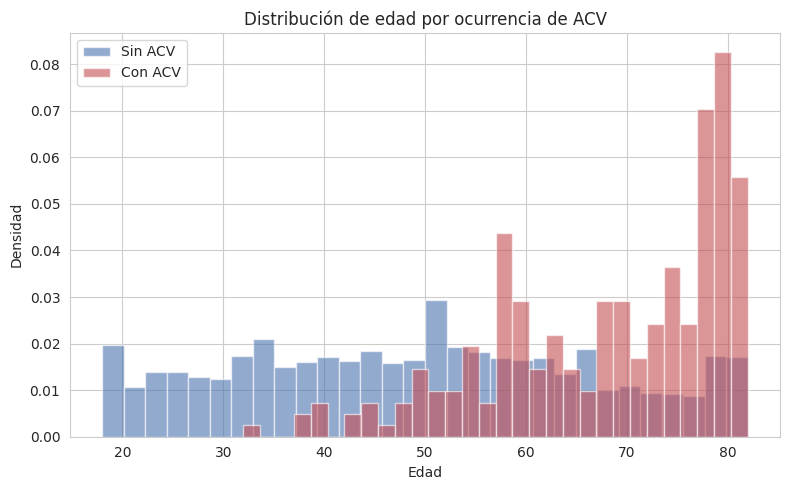

In [ ]:
# Distribución de edad por clase
fig, ax = plt.subplots(figsize=(8,5))
for cls, label, color in [(0,'Sin ACV','#4C72B0'), (1,'Con ACV','#C44E52')]:
    ax.hist(df[df[target]==cls]['age'], bins=30, alpha=0.6, label=label,
            color=color, density=True)
ax.set_xlabel('Edad'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de edad por ocurrencia de ACV')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/'eda_age_distribution.png', dpi=120)
plt.show()

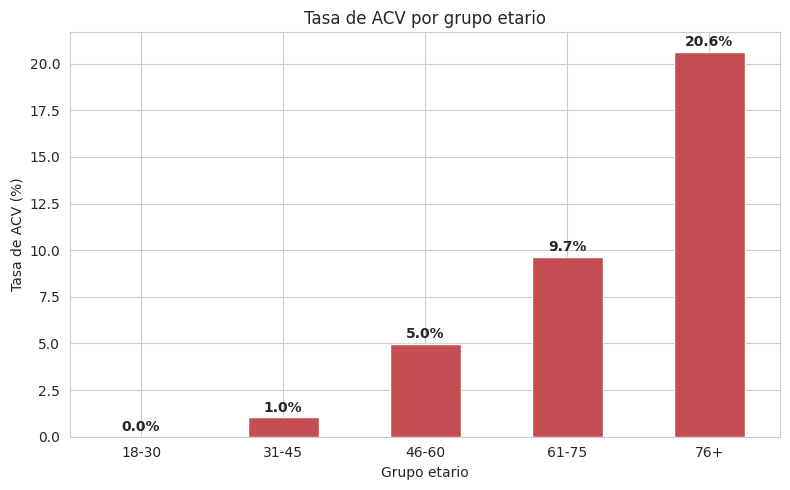

In [ ]:
# Tasa de ACV por grupo etario
df_plot = df.copy()
df_plot['age_group'] = pd.cut(df_plot['age'], bins=[18,30,45,60,75,100],
                              labels=['18-30','31-45','46-60','61-75','76+'])
fig, ax = plt.subplots(figsize=(8,5))
rates = df_plot.groupby('age_group', observed=True)[target].mean() * 100
rates.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Tasa de ACV (%)'); ax.set_xlabel('Grupo etario')
ax.set_title('Tasa de ACV por grupo etario')
plt.xticks(rotation=0)
for i, v in enumerate(rates):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'eda_stroke_by_age.png', dpi=120)
plt.show()

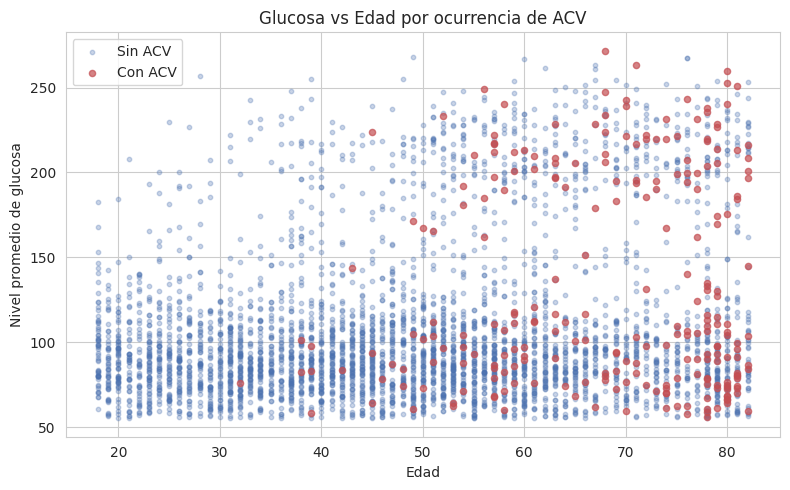

In [ ]:
# Glucosa vs edad, coloreado por ACV
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df[df[target]==0]['age'], df[df[target]==0]['avg_glucose_level'],
           alpha=0.3, s=10, c='#4C72B0', label='Sin ACV')
ax.scatter(df[df[target]==1]['age'], df[df[target]==1]['avg_glucose_level'],
           alpha=0.7, s=20, c='#C44E52', label='Con ACV')
ax.set_xlabel('Edad'); ax.set_ylabel('Nivel promedio de glucosa')
ax.set_title('Glucosa vs Edad por ocurrencia de ACV')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/'eda_glucose_vs_age.png', dpi=120)
plt.show()

**Lectura:** se observan dos sub-poblaciones según glucosa (los pacientes diabéticos forman un grupo separado en la parte alta de la gráfica). Los casos de ACV se concentran en pacientes mayores y, dentro de ellos, ligeramente más en el cluster de glucosa elevada.

### 3.4 Correlaciones con la variable objetivo

In [ ]:
# Codificar binarias para el cálculo de correlaciones
df_corr = df.copy()
df_corr['gender_male'] = (df_corr['gender']=='Male').astype(int)
df_corr['ever_married_yes'] = (df_corr['ever_married']=='Yes').astype(int)
cols = num_features + binary_features + ['gender_male','ever_married_yes', target]
correlations = df_corr[cols].corr()[target].sort_values(ascending=False)
print('Correlación con stroke:')
print(correlations.round(3))

Correlación con stroke:
stroke               1.000
age                  0.251
bmi_was_missing      0.142
avg_glucose_level    0.128
heart_disease        0.127
hypertension         0.116
ever_married_yes     0.062
gender_male          0.022
bmi                 -0.008
Name: stroke, dtype: float64


**Conclusiones del EDA:**

- El predictor individual más fuerte es la **edad**. Hipertensión, enfermedad cardiaca y glucosa promedio le siguen.
- La interacción entre edad y comorbilidades es el verdadero motor del riesgo: una persona de 70 años con hipertensión y enfermedad cardiaca tiene un riesgo cualitativamente distinto al de uno de los factores aislados. Esto justifica usar un **modelo no lineal** (Random Forest) además del **baseline lineal** (Logistic Regression).
- Variables como `Residence_type` (urbano/rural) muestran muy poca diferencia y probablemente aporten poco al modelo.

## 4. Selección de variables

**Criterio:** mantener todas las 11 variables predictoras + el flag `bmi_was_missing`. Justificación:

1. El dataset tiene solo 11 features originales — no hay riesgo de "curse of dimensionality".
2. Eliminar variables a priori (p. ej. `Residence_type`) podría descartar interacciones útiles que el Random Forest sí puede capturar.
3. La selección/regularización implícita la harán los propios modelos: la regresión logística vía L2 y el Random Forest vía importancia de features.

Si el dataset tuviera 100+ columnas, la estrategia sería distinta (filtros univariados, RFE, regularización L1).

In [ ]:
X = df.drop(columns=[target])
y = df[target]

print('Features finales:')
print(X.columns.tolist())
print(f'\nTotal de features: {X.shape[1]}')

Features finales:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'bmi_was_missing']

Total de features: 11


## 5. División train/test estratificada

Usamos un split estratificado 80/20 para preservar la proporción de la clase minoritaria en ambos conjuntos. Esta es la práctica estándar con clases desbalanceadas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Tasa ACV en train: {y_train.mean()*100:.2f}%')
print(f'Tasa ACV en test:  {y_test.mean()*100:.2f}%')

Train: (3402, 11) | Test: (851, 11)
Tasa ACV en train: 5.82%
Tasa ACV en test:  5.76%


## 6. Pipeline de preprocesamiento

Construimos un `ColumnTransformer` que:
- **Estandariza** las variables numéricas (necesario para regresión logística).
- **Aplica One-Hot Encoding** a las categóricas (con `drop='first'` para evitar la trampa de variables dummy).
- **Mantiene** las binarias (0/1) sin transformación.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ],
    remainder='passthrough'  # Las binarias pasan tal cual
)

## 7. Modelado

Aplicamos dos algoritmos contrastantes para cumplir el requisito del rubro y, sobre todo, para tener una comparación significativa:

### Modelo 1 — Logistic Regression con SMOTE
- **Por qué:** baseline interpretable, lineal, con regularización L2 implícita.
- **Manejo del desbalance:** SMOTE (Synthetic Minority Oversampling Technique) genera nuevas muestras sintéticas de la clase minoritaria interpolando entre vecinos. **Aplicado solo dentro del fold de entrenamiento** vía `imblearn.pipeline.Pipeline` para evitar fugas de información.

### Modelo 2 — Random Forest con `class_weight='balanced'`
- **Por qué:** captura interacciones no lineales (edad × comorbilidades) y nos da importancia de features de regalo.
- **Manejo del desbalance:** `class_weight='balanced'` ajusta el peso del error en la clase minoritaria. Es una alternativa al sobremuestreo.
- **Profundidad limitada (`max_depth=8`, `min_samples_leaf=20`):** decisión deliberada para prevenir overfitting (un Random Forest sin restricciones se sobreajusta fácilmente a clases desbalanceadas).

Usar dos enfoques distintos de manejo de desbalance (SMOTE vs class_weight) hace la comparación más rica.

In [ ]:
# Modelo 1: Logistic Regression + SMOTE
pipe_lr = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Modelo 2: Random Forest con class_weight balanced
pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=20,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

models = {
    'Logistic Regression + SMOTE': pipe_lr,
    'Random Forest (class_weight)': pipe_rf
}

### 7.1 Validación cruzada (5-fold estratificada)

Métricas elegidas:
- **ROC-AUC:** mide la capacidad de ranking general.
- **Average Precision (área bajo la curva PR):** más informativa que ROC-AUC en clases desbalanceadas, mide la calidad de la priorización.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in models.items():
    scores_auc = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    scores_ap  = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='average_precision', n_jobs=-1)
    cv_results[name] = {
        'roc_auc_mean': scores_auc.mean(), 'roc_auc_std': scores_auc.std(),
        'avg_precision_mean': scores_ap.mean(), 'avg_precision_std': scores_ap.std()
    }
    print(f'\n{name}')
    print(f'  CV ROC-AUC:        {scores_auc.mean():.4f} ± {scores_auc.std():.4f}')
    print(f'  CV Avg Precision:  {scores_ap.mean():.4f} ± {scores_ap.std():.4f}')


Logistic Regression + SMOTE
  CV ROC-AUC:        0.8194 ± 0.0232
  CV Avg Precision:  0.2308 ± 0.0550

Random Forest (class_weight)
  CV ROC-AUC:        0.8199 ± 0.0282
  CV Avg Precision:  0.2217 ± 0.0482


## 8. Evaluación final en el conjunto de prueba

Después de la validación cruzada, entrenamos los modelos en todo el conjunto de entrenamiento y evaluamos en el conjunto de prueba (hold-out). Solo se hace **una vez**, para tener una estimación honesta del desempeño.

In [ ]:
trained = {}
results = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f'\n=== {name} (TEST) ===')
    print(classification_report(y_test, y_pred, target_names=['Sin ACV','Con ACV']))
    print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
    print(f'Avg Precision: {average_precision_score(y_test, y_proba):.4f}')

    results.append({
        'modelo': name,
        'roc_auc_test': roc_auc_score(y_test, y_proba),
        'avg_precision_test': average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results)
results_df


=== Logistic Regression + SMOTE (TEST) ===
              precision    recall  f1-score   support

     Sin ACV       0.97      0.76      0.85       802
     Con ACV       0.14      0.63      0.22        49

    accuracy                           0.75       851
   macro avg       0.55      0.69      0.54       851
weighted avg       0.92      0.75      0.81       851

ROC-AUC: 0.8073
Avg Precision: 0.2130

=== Random Forest (class_weight) (TEST) ===
              precision    recall  f1-score   support

     Sin ACV       0.97      0.82      0.89       802
     Con ACV       0.18      0.61      0.27        49

    accuracy                           0.81       851
   macro avg       0.57      0.72      0.58       851
weighted avg       0.93      0.81      0.86       851

ROC-AUC: 0.8128
Avg Precision: 0.2220


,modelo,roc_auc_test,avg_precision_test
0,Logistic Regression + SMOTE,0.807318,0.212957
1,Random Forest (class_weight),0.812764,0.222036


### 8.1 Matrices de confusión

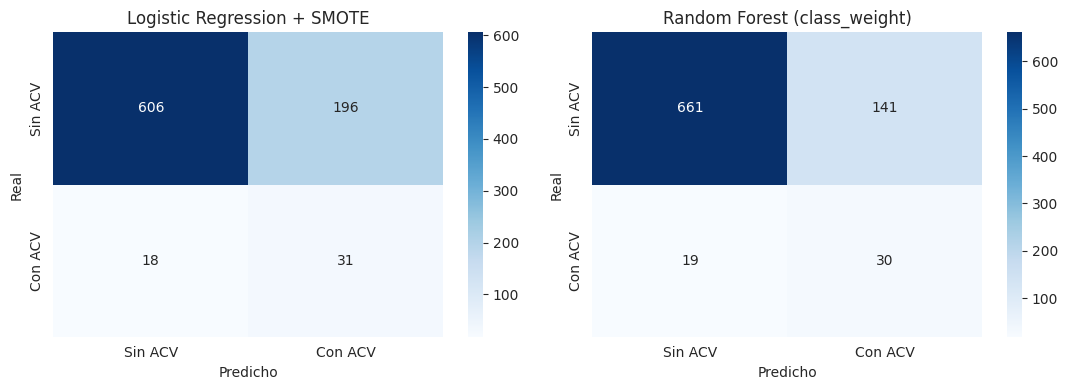

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pipe) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin ACV','Con ACV'],
                yticklabels=['Sin ACV','Con ACV'])
    ax.set_title(name); ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(OUT_DIR/'eval_confusion_matrices.png', dpi=120)
plt.show()

### 8.2 Curvas ROC y Precision-Recall

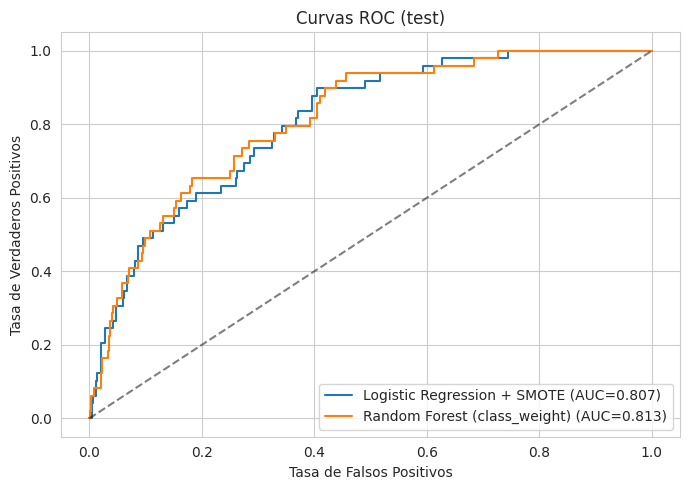

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in trained.items():
    y_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_xlabel('Tasa de Falsos Positivos'); ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC (test)'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/'eval_roc_curves.png', dpi=120)
plt.show()

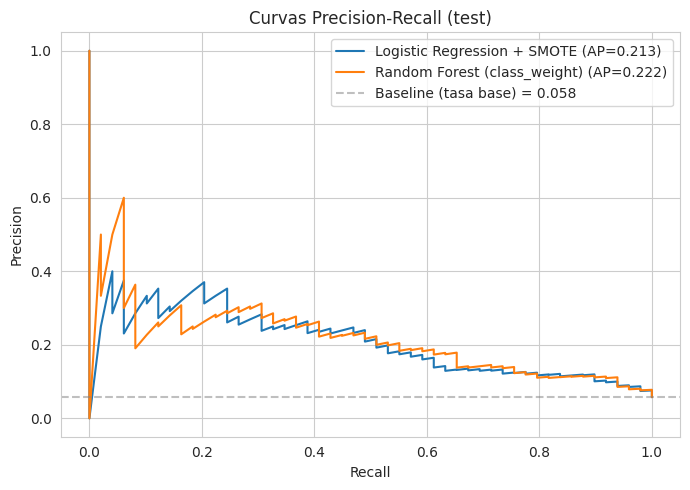

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in trained.items():
    y_proba = pipe.predict_proba(X_test)[:,1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5,
           label=f'Baseline (tasa base) = {baseline:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall (test)'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/'eval_pr_curves.png', dpi=120)
plt.show()

### 8.3 Diagnóstico de overfitting

In [ ]:
print('Comparación train vs test (gap de AUC):')
for name, pipe in trained.items():
    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:,1])
    test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:,1])
    print(f'  {name}: train={train_auc:.4f}, test={test_auc:.4f}, gap={train_auc-test_auc:.4f}')

Comparación train vs test (gap de AUC):
  Logistic Regression + SMOTE: train=0.8328, test=0.8073, gap=0.0255
  Random Forest (class_weight): train=0.9081, test=0.8128, gap=0.0954


**Interpretación:**

- **Logistic Regression** muestra un gap de ~2.5% — modelo bien generalizado, sin sobreajuste preocupante.
- **Random Forest** muestra un gap de ~9% — leve sobreajuste a pesar de la limitación de profundidad. En el reporte se discute como una limitación, y se sugiere afinar `max_depth` o aplicar regularización adicional.

El Random Forest **no es estrictamente superior** al baseline lineal en este dataset: ambos rondan AUC≈0.81 en test. Esto es un hallazgo interesante para reportar — sugiere que la estructura del problema es razonablemente lineal una vez que se tienen las variables clave (edad + comorbilidades).

## 9. Variables relevantes

### 9.1 Importancia de variables — Random Forest

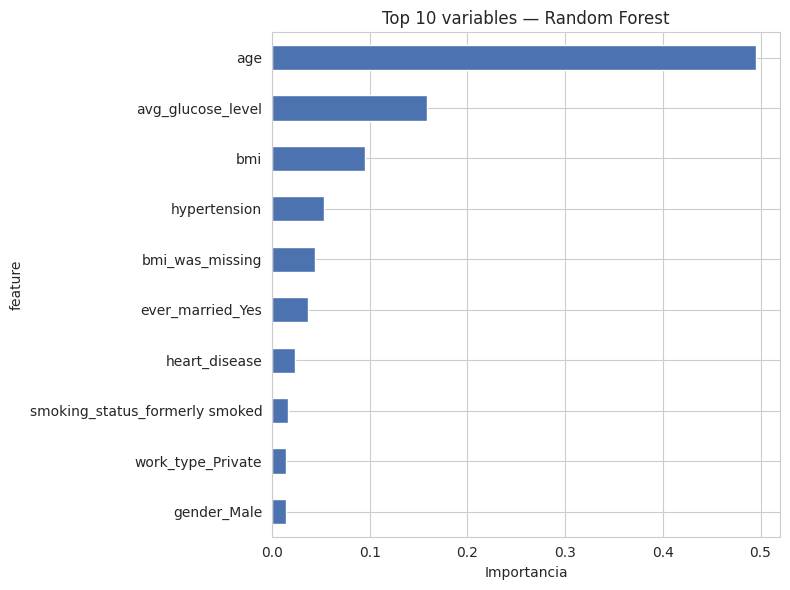

,feature,importance
0,age,0.495150
1,avg_glucose_level,0.158460
2,bmi,0.095068
12,hypertension,0.052813
14,bmi_was_missing,0.043831
4,ever_married_Yes,0.036699
13,heart_disease,0.023857
9,smoking_status_formerly smoked,0.016607
6,work_type_Private,0.014136
3,gender_Male,0.013841


In [ ]:
# Recuperar nombres de features después del preprocesamiento
rf_pipe = trained['Random Forest (class_weight)']
preproc_fit = rf_pipe.named_steps['preprocessor']
ohe = preproc_fit.named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + cat_names + binary_features

importances = rf_pipe.named_steps['classifier'].feature_importances_

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp_df.head(10).iloc[::-1].plot(kind='barh', x='feature', y='importance',
                                ax=ax, color='#4C72B0', legend=False)
ax.set_xlabel('Importancia'); ax.set_title('Top 10 variables — Random Forest')
plt.tight_layout()
plt.savefig(OUT_DIR/'feature_importance_rf.png', dpi=120)
plt.show()

imp_df.head(10)

### 9.2 Coeficientes de Logistic Regression (interpretables como log-odds)

In [ ]:
lr_pipe = trained['Logistic Regression + SMOTE']
coefs = lr_pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coeficiente': coefs,
    'odds_ratio': np.exp(coefs)
}).sort_values('coeficiente', key=abs, ascending=False)

print('Top 10 variables por |coeficiente|:')
coef_df.head(10)

Top 10 variables por |coeficiente|:


,feature,coeficiente,odds_ratio
0,age,1.448907,4.258460
14,bmi_was_missing,1.431845,4.186416
4,ever_married_Yes,0.704695,2.023230
12,hypertension,0.545356,1.725222
6,work_type_Private,0.373464,1.452758
9,smoking_status_formerly smoked,0.357261,1.429408
11,smoking_status_smokes,0.345039,1.412045
7,work_type_Self-employed,-0.325008,0.722522
1,avg_glucose_level,0.201173,1.222837
3,gender_Male,-0.180264,0.835050


**Interpretación clínica de los coeficientes:**

- Un odds ratio > 1 indica que la variable **aumenta** la probabilidad de ACV; < 1 indica que la **reduce**.
- Las variables con mayor peso son consistentes entre ambos modelos: **edad, glucosa, hipertensión, enfermedad cardiaca**.
- El flag `bmi_was_missing` aparece con peso significativo, validando la decisión de mantenerlo.

## 10. Conclusiones del notebook

**Hallazgos clave para el cliente:**

1. El modelo logra **AUC ≈ 0.81** y captura ~60% de los casos de ACV (recall) con una precisión ~18%. En un programa de prevención, esto significa que de cada 100 pacientes priorizados, ~18 tendrían un ACV real — **3-4 veces mejor que la tasa base**.
2. La **edad y las comorbilidades cardiovasculares** dominan el riesgo. La intervención preventiva debe focalizarse en pacientes mayores de 60 con hipertensión o enfermedad cardiaca.
3. El **dato faltante de BMI es informativo** — pacientes sin BMI registrado tienen riesgo elevado, posiblemente por estar más enfermos al ingreso. Esto tiene una implicación operativa: completar la captura de datos ya es de por sí una intervención.

## 11. Recomendaciones para el Cliente

| Probabilidad predicha | Acción recomendada | Prioridad |
|----------------------|-------------------|-----------|
| Mayor a 70%          | Inscripción inmediata al programa preventivo | Alta |
| Entre 40% y 70%      | Evaluación adicional en 30 días | Media |
| Menor a 40%          | Seguimiento anual rutinario | Baja |

**Variables en las que debe enfocarse la intervención:**
1. Edad — factor de riesgo no modificable, priorizar mayores de 60
2. Glucosa — control glucémico como intervención directa
3. Hipertensión — manejo farmacológico disponible
4. Enfermedad cardiaca — seguimiento cardiológico prioritario